In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
#import scvi
from scipy import sparse
import sys
import os
sys.path.append(os.path.abspath(".."))
from speciesot_helpers import match_cells_by_celltype_tissue

/n/home01/jzhou1125/miniforge3/envs/analysis/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
mouse_d0 = sc.read_10x_mtx('/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/tb/data/mouse_bcg/PBS')

In [3]:
mouse_d0

AnnData object with n_obs × n_vars = 737280 × 27998
    var: 'gene_ids', 'feature_types'

In [4]:
mouse_d28 = sc.read_10x_mtx('/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/tb/data/mouse_bcg/BCG')

In [5]:
mouse_d28

AnnData object with n_obs × n_vars = 737280 × 27998
    var: 'gene_ids', 'feature_types'

In [6]:
sc.pp.filter_cells(mouse_d0, min_genes=500)
sc.pp.filter_genes(mouse_d0, min_cells=5)

In [7]:
sc.pp.filter_cells(mouse_d28, min_genes=500)
sc.pp.filter_genes(mouse_d28, min_cells=5)

In [8]:
mouse_genes = mouse_d28.var.index.tolist()

In [9]:
# mitochondrial genes
mouse_d0.var["mt"] = mouse_d0.var['gene_ids'].str.startswith("mt-")
# ribosomal genes
mouse_d0.var["ribo"] = mouse_d0.var['gene_ids'].str.startswith(("Rps", "Rpl"))
# hemoglobin genes
mouse_d0.var["hb"] = mouse_d0.var['gene_ids'].str.startswith(("Hba", "Hbb", "Hbd", "Hbe", "Hbg"))

In [10]:
sc.pp.calculate_qc_metrics(
    mouse_d0,
    qc_vars=["mt", "ribo", "hb"],
    percent_top=None,
    log1p=False,
    inplace=True,
)

In [11]:
mouse_d0 = mouse_d0[mouse_d0.obs["pct_counts_mt"] <= 4.7].copy()

In [12]:
# mitochondrial genes
mouse_d28.var["mt"] = mouse_d28.var['gene_ids'].str.startswith("mt-")
# ribosomal genes
mouse_d28.var["ribo"] = mouse_d28.var['gene_ids'].str.startswith(("Rps", "Rpl"))
# hemoglobin genes
mouse_d28.var["hb"] = mouse_d28.var['gene_ids'].str.startswith(("Hba", "Hbb", "Hbd", "Hbe", "Hbg"))

In [13]:
sc.pp.calculate_qc_metrics(
    mouse_d28,
    qc_vars=["mt", "ribo", "hb"],
    percent_top=None,
    log1p=False,
    inplace=True,
)

In [14]:
mouse_d28 = mouse_d28[mouse_d28.obs["pct_counts_mt"] <= 4.7].copy()

In [15]:
mouse_d0

AnnData object with n_obs × n_vars = 6768 × 14614
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [16]:
mouse_d28

AnnData object with n_obs × n_vars = 2248 × 13132
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [17]:
mouse_all = ad.concat(
    [mouse_d0, mouse_d28],
    join="inner",        # keeps only common genes
    label="day",       # optional: adds batch column
    keys=[0, 28]
)

/n/home01/jzhou1125/miniforge3/envs/analysis/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
mouse_all.layers["counts"] = mouse_all.X.copy()

sc.pp.normalize_total(mouse_all, target_sum=1e4)
sc.pp.log1p(mouse_all)

sc.pp.highly_variable_genes(
    mouse_all,
    n_top_genes=2000,
    flavor='seurat'
)

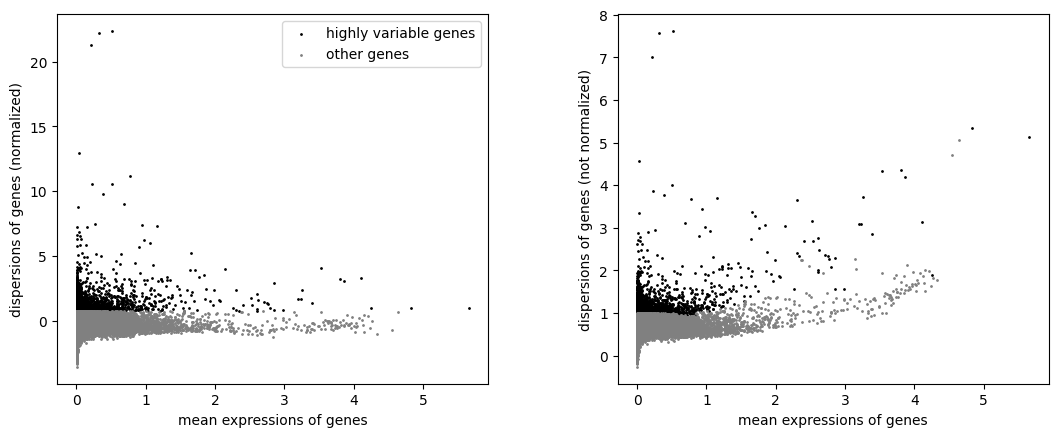

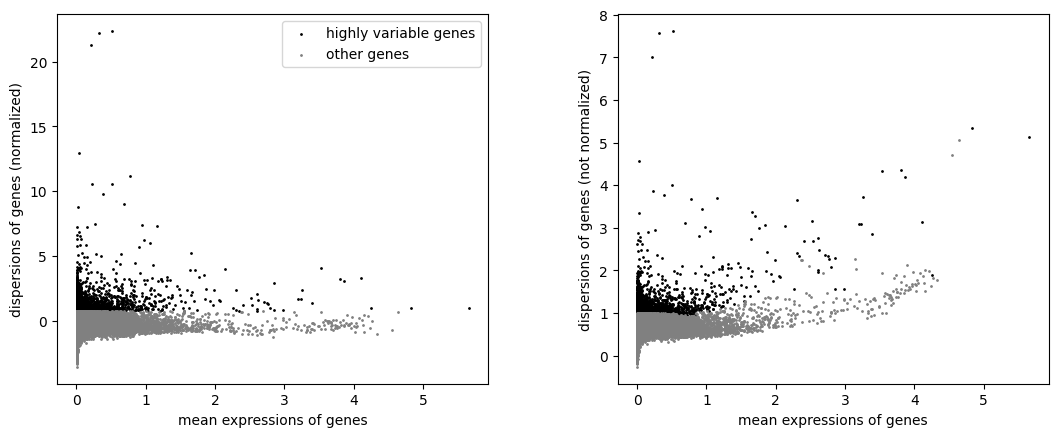

In [19]:
sc.pl.highly_variable_genes(mouse_all)

In [20]:
sc.tl.pca(mouse_all)

In [21]:
sc.pp.neighbors(mouse_all)

In [22]:
sc.tl.umap(mouse_all)

In [23]:
sc.tl.leiden(mouse_all, flavor="igraph", n_iterations=2)

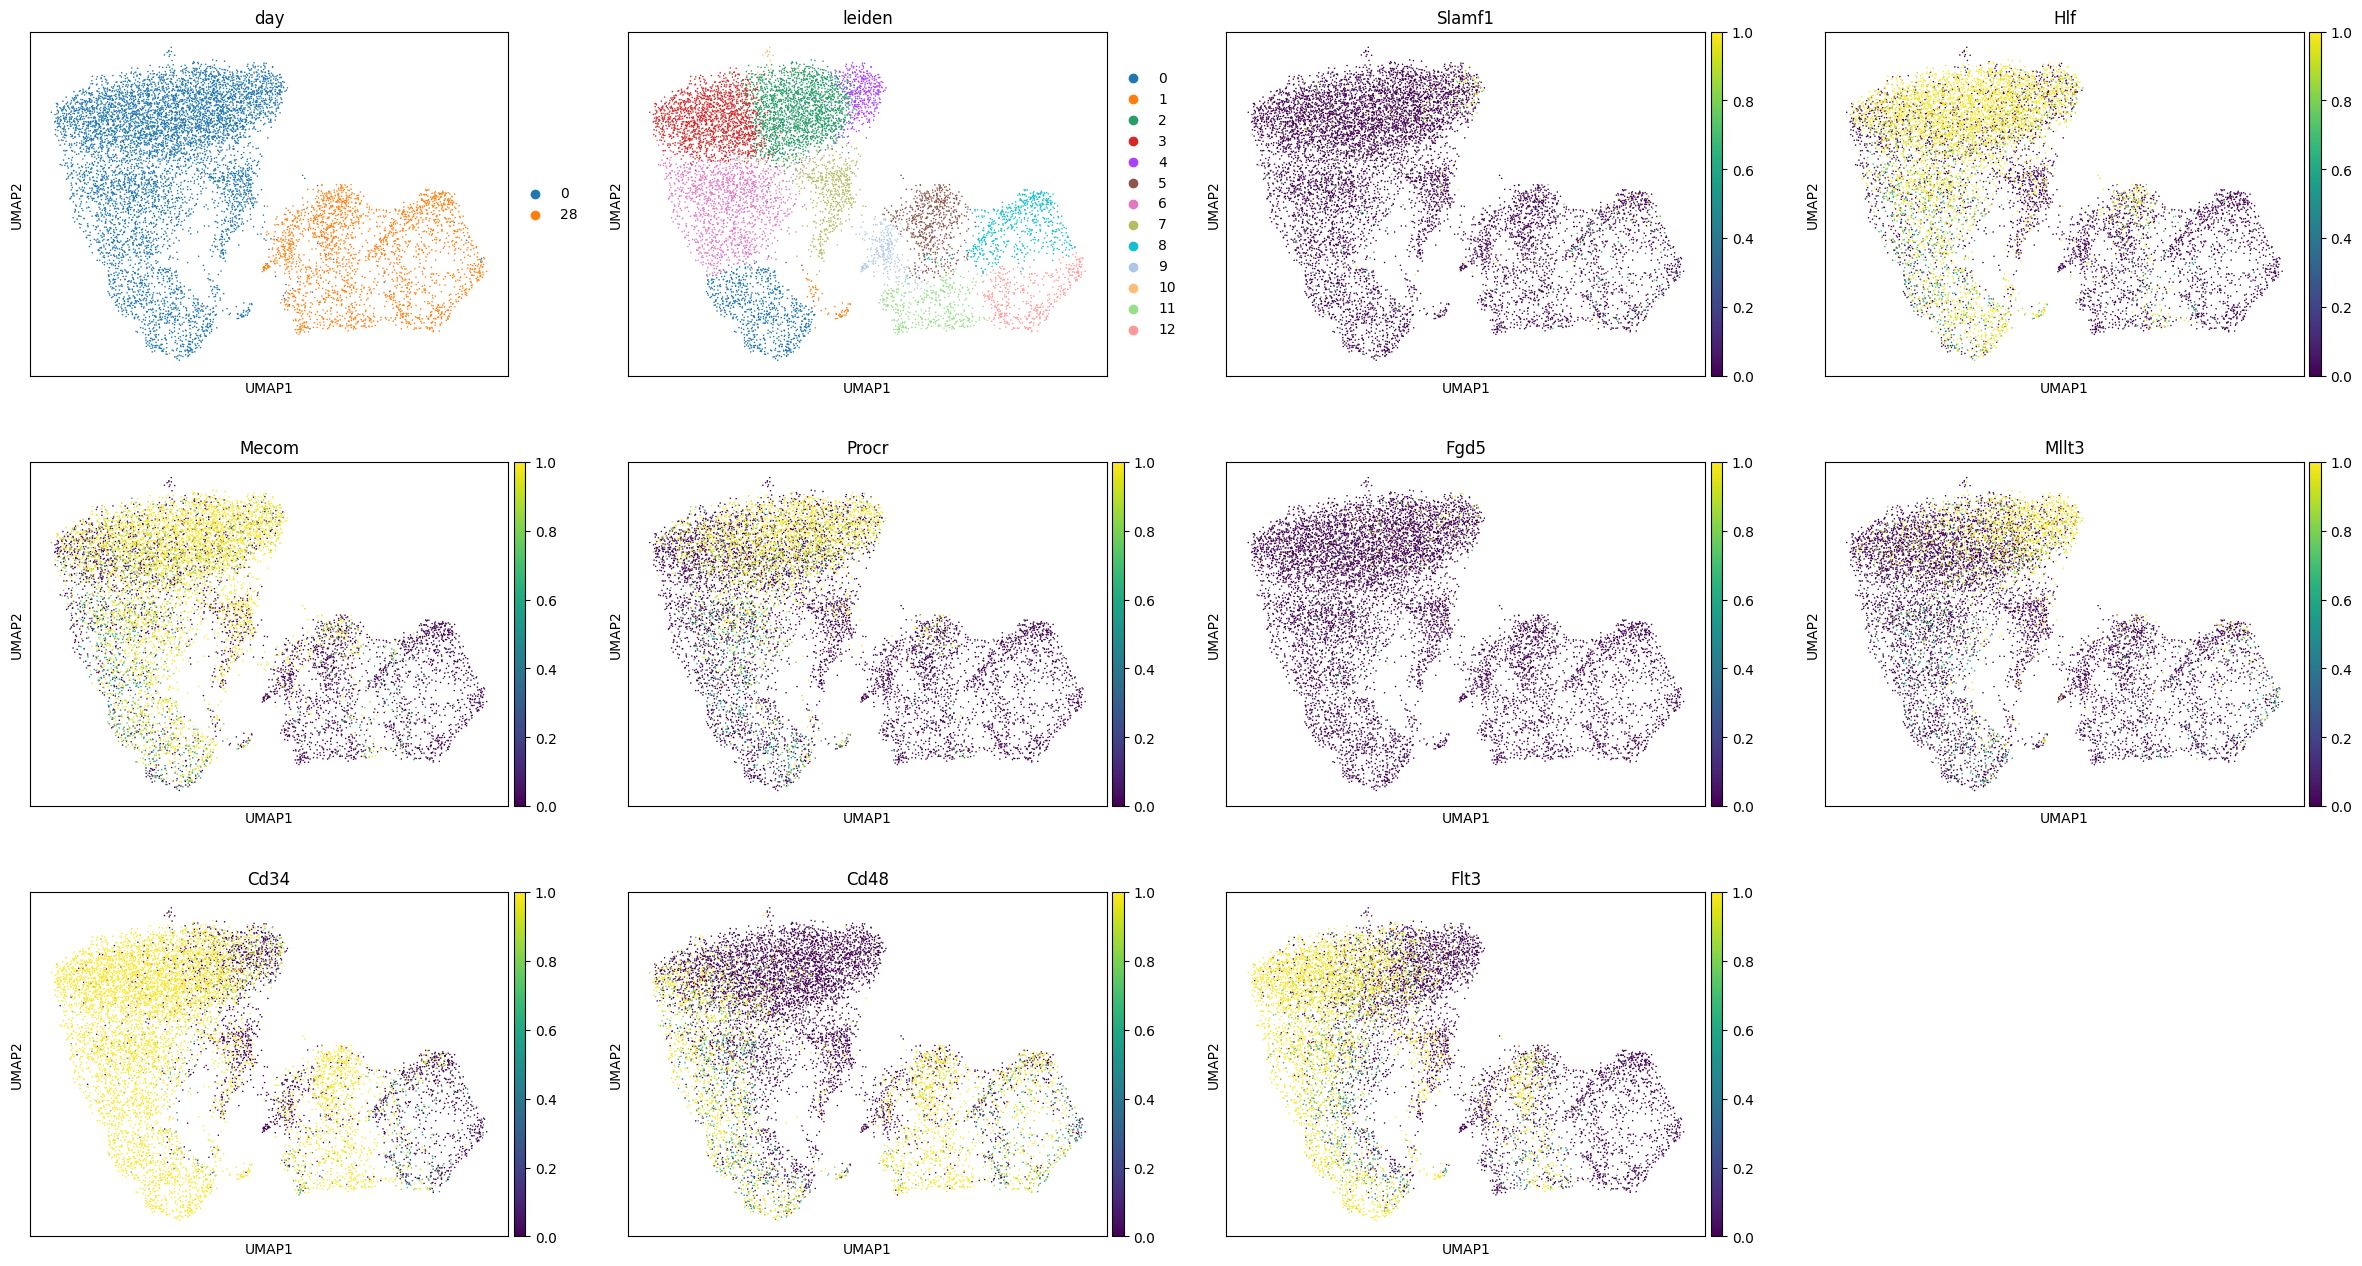

In [24]:
sc.pl.umap(
    mouse_all,
    color=['day','leiden','Slamf1','Hlf', 'Mecom', 'Procr', 'Fgd5', 'Mllt3','Cd34','Cd48','Flt3'],
    # Setting a smaller point size to get prevent overlap
    size=5,
    vmax=1.0,
)

In [25]:
# cluster 2 is d0 lthsc, clusters 7 and 9 are d28 lthsc

In [26]:
d0_lthsc = mouse_all[(mouse_all.obs['day']==0) & (mouse_all.obs['leiden']=='4')]

In [27]:
d28_lthsc = mouse_all[(mouse_all.obs['day']==28) & (mouse_all.obs['leiden'].isin(['8','12']))]

In [28]:
d0_lthsc.obs['cell_type'] = 'LT-HSC'
d28_lthsc.obs['cell_type'] = 'LT-HSC'

/tmp/ipykernel_767204/819009527.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  d0_lthsc.obs['cell_type'] = 'LT-HSC'
/tmp/ipykernel_767204/819009527.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  d28_lthsc.obs['cell_type'] = 'LT-HSC'


### Loading in atlas mouse data

In [29]:
MOUSE_H5AD = "/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/data/tabula_muris/sampled_mouse_shared.h5ad"
HUMAN_H5AD = "/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/data/tabula_sapiens/sampled_human_shared.h5ad"

In [30]:
mouse_full = sc.read_h5ad(MOUSE_H5AD)
human_full = sc.read_h5ad(HUMAN_H5AD)

mouse_B = mouse_full.raw.to_adata()
human_B = human_full.raw.to_adata()

mouse_B.obs = mouse_full.obs.copy()
human_B.obs = human_full.obs.copy()

mouse_B_Smart = mouse_B[mouse_B.obs['assay']=="Smart-seq2"]
mouse_B = mouse_B[mouse_B.obs['assay']=="10x 3' v2"]
human_B = human_B[human_B.obs['assay']=="10x 3' v3"]


In [31]:
mouse_matched_B, human_matched_B = match_cells_by_celltype_tissue(
    mouse_B, human_B,
    cell_type_key="cell_type_ontology_term_id",
    tissue_key="tissue_ontology_term_id",
)

for a in [mouse_matched_B, human_matched_B]:
    a.layers["counts"] = a.X.copy()
    a.X = a.X.astype("float32")
    sc.pp.normalize_total(a, target_sum=1e4)
    sc.pp.log1p(a)

In [32]:
shared_immune_cell_types = ['T cell','HPSC','macrophage','monocyte','neutrophil','plasma cell','erythrocyte','NK cell','B cell','basophil','dendritic cell']

In [33]:
#mouse1 = mouse_matched_B[mouse_matched_B.obs['tissue_free_annotation']=="Marrow"]

In [34]:
mouse1_immune = mouse_matched_B[mouse_matched_B.obs['shared_cell_type'].isin(shared_immune_cell_types)]

In [35]:
mouse_B_Smart

View of AnnData object with n_obs × n_vars = 17481 × 18024
    obs: 'batch', 'tissue_FACS_droplet', 'free_annotation', 'n_counts', 'n_genes', 'louvain', 'leiden', 'age', 'method', 'donor_id', 'subtissue', 'tissue_free_annotation', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'FACS.selection', 'tissue_original', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'shared_cell_type'
    var: 'index', 'n_cells-0', 'n_cells-1', 'gene_symbols', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'age_colors', 'citation', 'leiden', 'louvain', 'louvain_colors', 'method_colors', 'neighbors', 'organism', 'organism_ontology_term_id', 'pca', 'schema_reference', 's

In [36]:
# Check beneath there, we have the 7 10x 3' v2 HSC
mouse_B.obs[['assay','cell_type']].value_counts()

assay      cell_type                                 
10x 3' v2  alveolar macrophage                           1000
           hematopoietic precursor cell                  1000
           naive T cell                                  1000
           immature T cell                               1000
           intermediate monocyte                          992
           lung macrophage                                992
           plasma cell                                    983
           classical monocyte                             977
           double negative thymocyte                      971
           smooth muscle cell                             932
           mesenchymal stem cell                          906
           T cell                                         900
           non-classical monocyte                         869
           B cell                                         858
           bladder urothelial cell                        805
           pancr

In [37]:
mouse_B_Smart.obs[['assay','cell_type']].value_counts()

assay       cell_type                                 
Smart-seq2  microglial cell                               1000
            hematopoietic stem cell                        993
            large intestine goblet cell                    907
            naive B cell                                   872
            CD4-positive, alpha-beta T cell                669
            fibroblast of cardiac tissue                   642
            CD8-positive, alpha-beta T cell                562
            pancreatic A cell                              521
            precursor B cell                               500
            brain pericyte                                 484
            neuron                                         484
            endothelial cell of hepatic sinusoid           476
            thymocyte                                      472
            bronchial smooth muscle cell                   471
            aortic endothelial cell                        467


In [38]:
mouse1_immune.obs[['assay','cell_type']].value_counts()

assay      cell_type                      
10x 3' v2  hematopoietic precursor cell       613
           intermediate monocyte              504
           non-classical monocyte             365
           natural killer cell                351
           B cell                             153
           basophil                           143
           plasma cell                        132
           T cell                              76
           classical monocyte                  74
           macrophage                          69
           monocyte                            36
           CD8-positive, alpha-beta T cell     31
           plasmacytoid dendritic cell         27
           CD4-positive, alpha-beta T cell     25
           myeloid dendritic cell               5
           neutrophil                           4
           erythrocyte                          1
Name: count, dtype: int64

### Combine mouse atlas and BCG data

In [39]:
mouse1_immune.var.index = mouse1_immune.var['index']

/tmp/ipykernel_767204/2458266543.py:1: ImplicitModificationWarning: Trying to modify index of attribute `.var` of view, initializing view as actual.
  mouse1_immune.var.index = mouse1_immune.var['index']


In [40]:
mouse_combined = ad.concat(
    [mouse1_immune, d0_lthsc, d28_lthsc],
    join="inner",        # keeps only common genes
    label="study",       # optional: adds batch column
    keys=['atlas', 'bcg_control', 'bcg']
)

/n/home01/jzhou1125/miniforge3/envs/analysis/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [41]:
mouse_combined

AnnData object with n_obs × n_vars = 4015 × 10866
    obs: 'n_genes', 'leiden', 'cell_type', 'study'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'

In [42]:
sc.pp.highly_variable_genes(
    mouse_combined,
    n_top_genes=2000,
    flavor='seurat'
)

In [43]:
sc.tl.pca(mouse_combined)

In [44]:
sc.pp.neighbors(mouse_combined)

In [45]:
sc.tl.umap(mouse_combined)

In [46]:
sc.tl.leiden(mouse_combined, flavor="igraph", n_iterations=2)

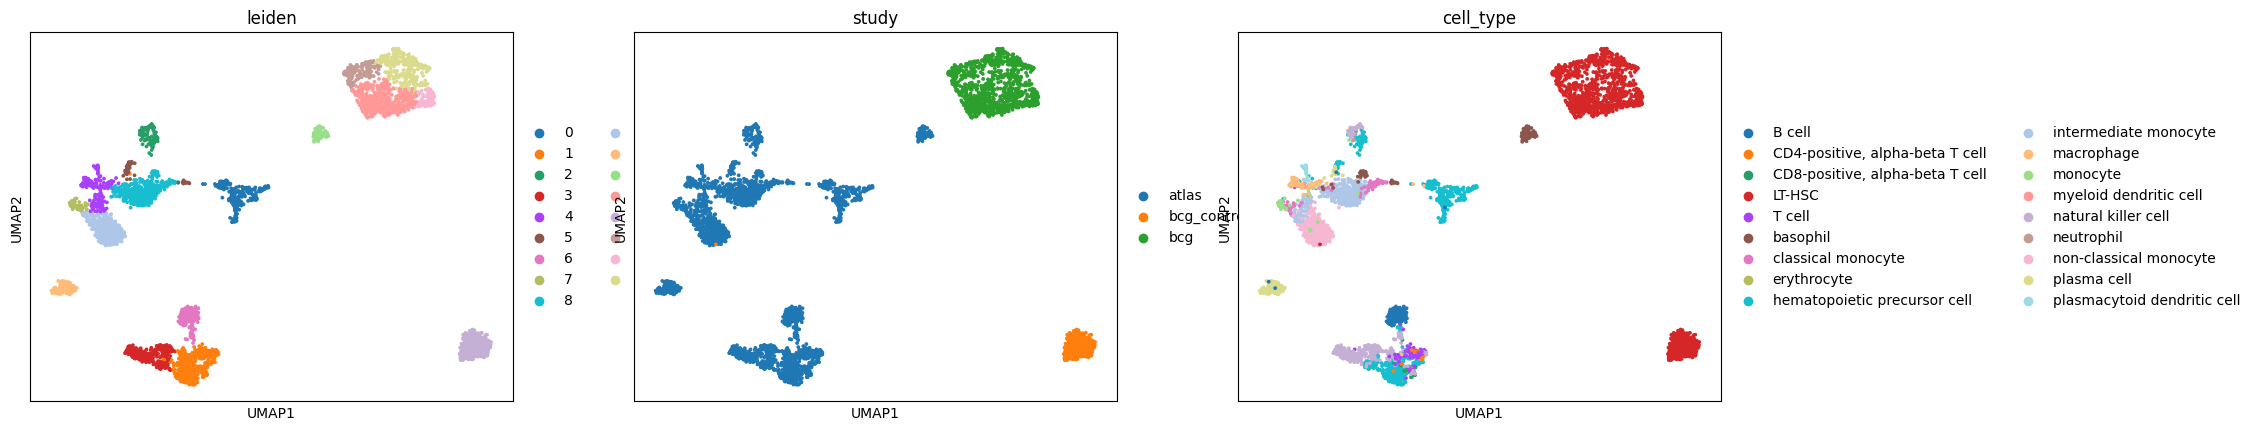

In [47]:
sc.pl.umap(mouse_combined, color=["leiden","study","cell_type"])

In [48]:
# Identify LT-HSC in atlas HPSC

In [49]:
atlas_hspc = mouse1_immune[mouse1_immune.obs['cell_type']=='hematopoietic precursor cell']

In [50]:
sc.tl.pca(atlas_hspc)

/n/home01/jzhou1125/miniforge3/envs/analysis/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:359: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


In [51]:
sc.pp.neighbors(atlas_hspc)

In [52]:
sc.tl.leiden(atlas_hspc, flavor="igraph", n_iterations=2, resolution=2)

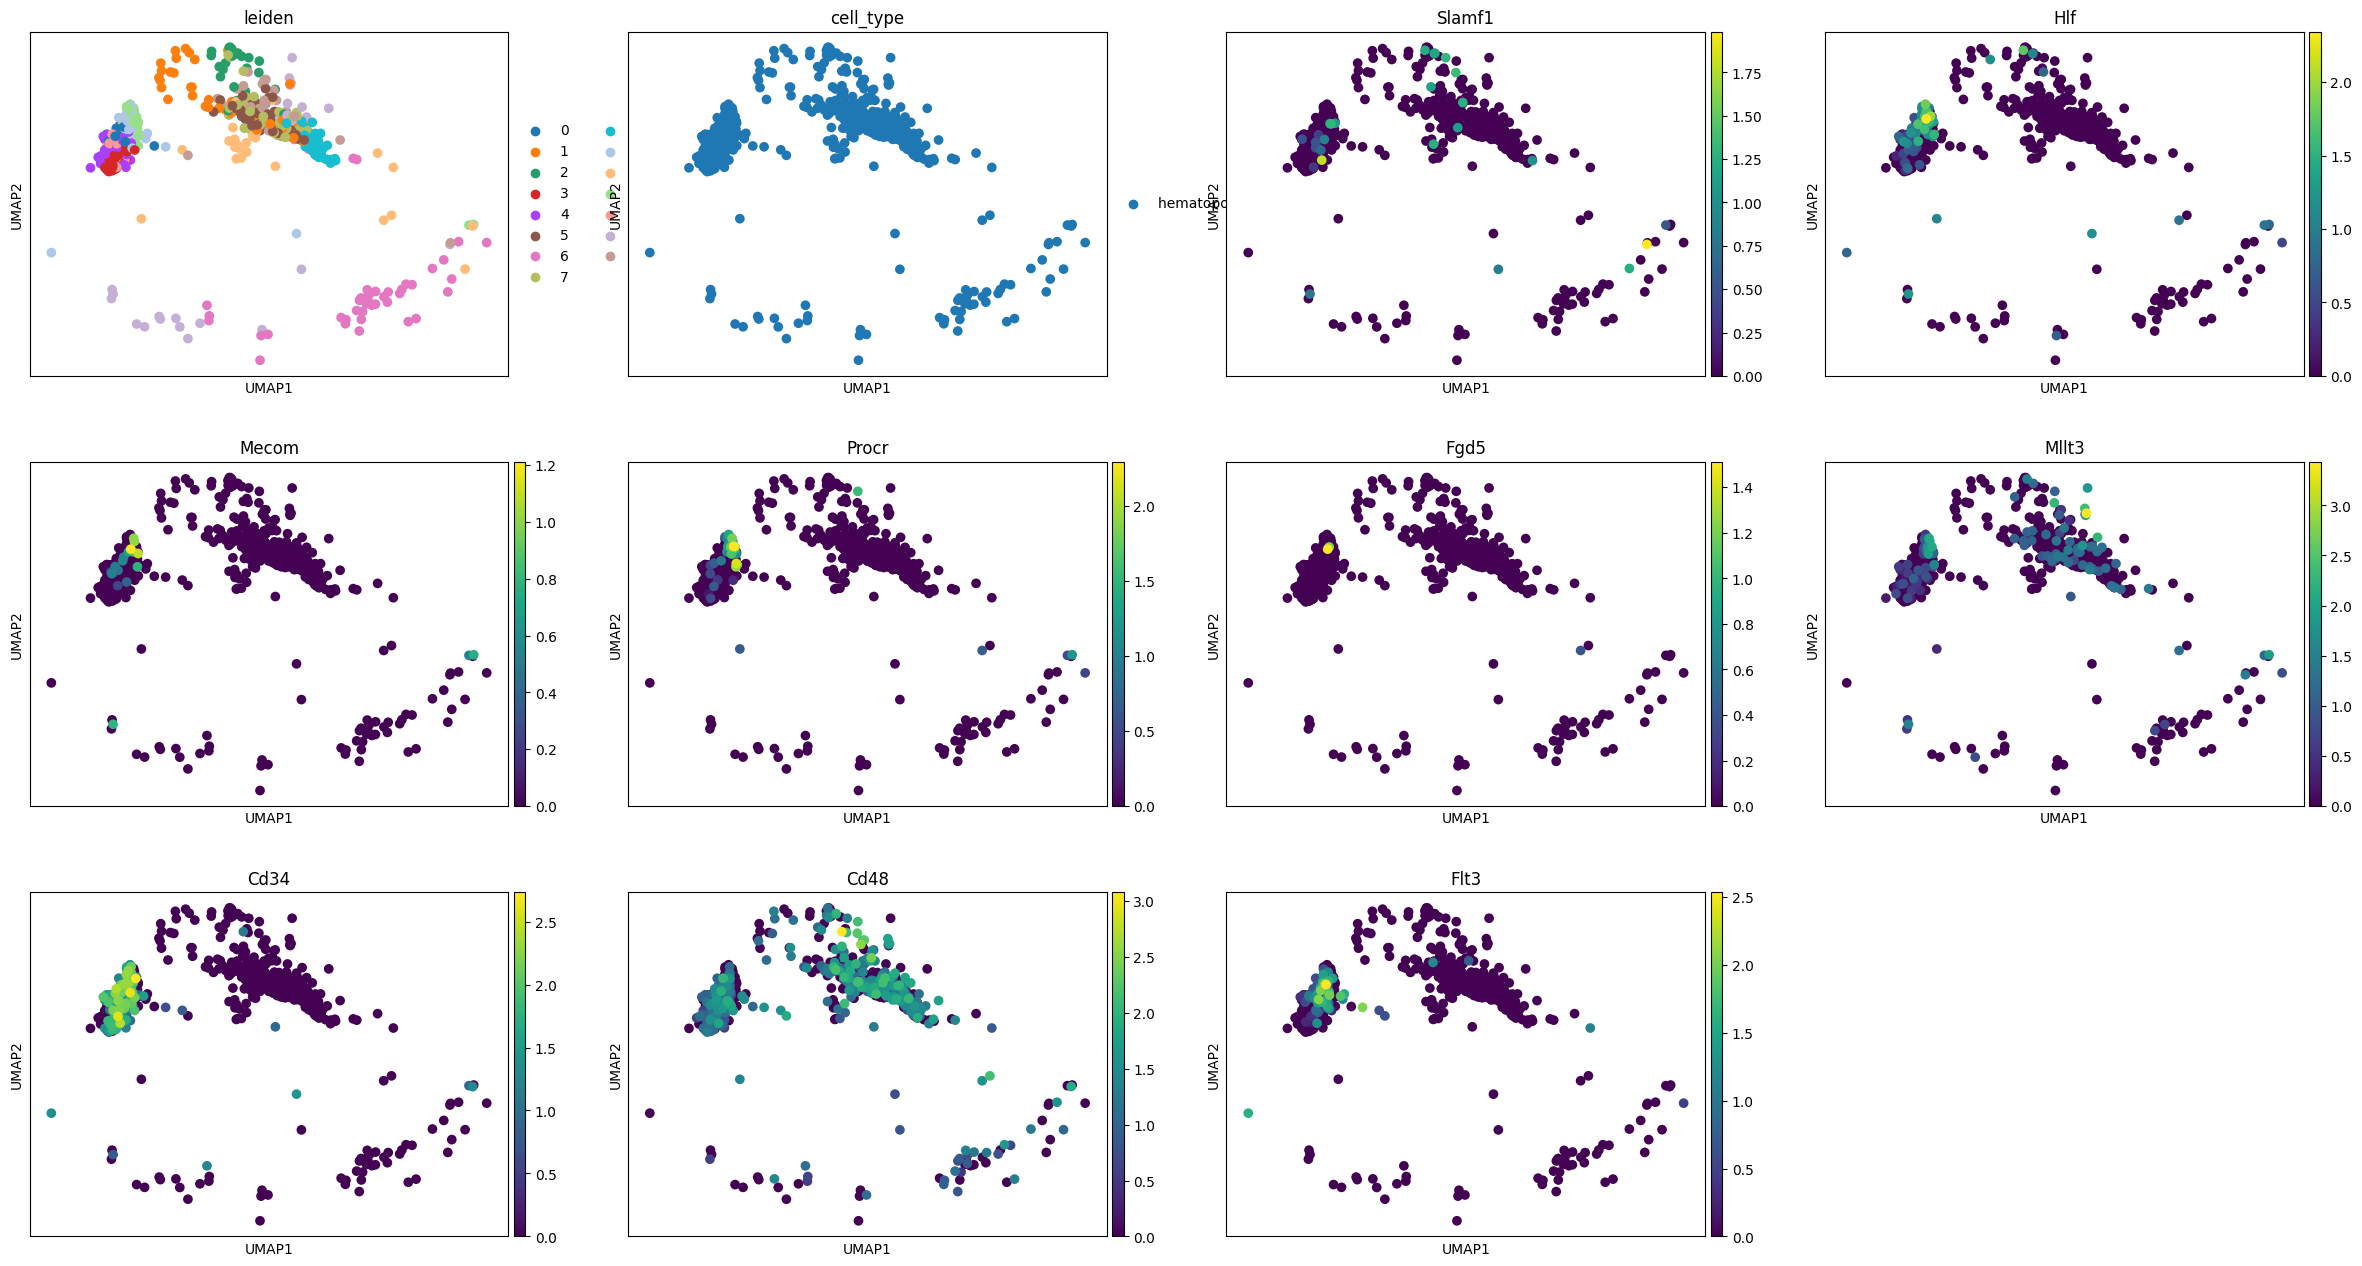

In [53]:
sc.pl.umap(atlas_hspc, color=["leiden","cell_type",'Slamf1','Hlf', 'Mecom', 'Procr', 'Fgd5','Mllt3','Cd34','Cd48','Flt3'])

In [54]:
atlas_lthsc = mouse_combined[mouse_combined.obs['leiden']=='11']

In [55]:
mouse1.obs_names

NameError: name 'mouse1' is not defined

In [ ]:
mouse1.obs['tissue_free_annotation'].value_counts()

tissue_free_annotation
Marrow    723
Name: count, dtype: int64

In [ ]:
mouse1[atlas_lthsc.obs_names].obs['tissue_free_annotation'].value_counts()

KeyError: "Values ['AAACGGGCATTAGCCA-1', 'AACCATGGTCATTAGC-1', 'AACGTTGAGGCTAGCA-1', 'AACTCAGAGAGGTTGC-1', 'AACTCTTGTACATCCA-1', 'AAGACCTCAAAGTCAA-1', 'AAGACCTGTACCAGTT-1', 'AAGCCGCCAGGGTACA-1', 'AAGCCGCGTAGGGTAC-1', 'AAGGAGCTCACAGTAC-1', 'AAGGCAGTCCATGAGT-1', 'AAGTCTGGTGAGGGTT-1', 'AATCCAGAGAGCTATA-1', 'AATCGGTAGGATATAC-1', 'ACACCAAAGATATGCA-1', 'ACACCGGAGAGTGACC-1', 'ACACCGGAGGGAGTAA-1', 'ACAGCTATCCCTAACC-1', 'ACATACGAGCCAACAG-1', 'ACATCAGAGTGGTAAT-1', 'ACATCAGGTACAGTGG-1', 'ACCAGTAAGTTACGGG-1', 'ACGCAGCCAGATTGCT-1', 'ACGCCAGTCAGAGACG-1', 'ACGGAGATCTATCGCC-1', 'ACGGGCTCATTCCTCG-1', 'ACTATCTAGGCAGTCA-1', 'ACTGAGTAGTACCGGA-1', 'ACTGAGTCAAAGGCGT-1', 'ACTGATGAGAATCTCC-1', 'ACTGATGGTAATAGCA-1', 'ACTGTCCCATGTCTCC-1', 'ACTTACTAGCCACTAT-1', 'ACTTTCAAGTACCGGA-1', 'ACTTTCACAAACAACA-1', 'AGAGCGATCAGTACGT-1', 'AGAGCTTGTGACTACT-1', 'AGAGTGGAGAGCTATA-1', 'AGCATACTCTAACTTC-1', 'AGCGGTCCACTAAGTC-1', 'AGGGAGTTCTTGAGGT-1', 'AGGGATGTCTGGCGTG-1', 'AGGTCATCAGACACTT-1', 'AGGTCATTCAGTCCCT-1', 'AGGTCCGCATGG

In [ ]:
mask = mouse_combined.obs_names.isin(atlas_lthsc.obs_names)

NameError: name 'atlas_lthsc' is not defined

In [ ]:
mouse_combined.obs.loc[mask, "cell_type"] = "LT-HSC"

In [ ]:
mouse_combined.obs["cell_type"] = mouse_combined.obs["cell_type"].cat.add_categories(["LT-HSC treated"])
mouse_combined.obs.loc[mouse_combined.obs["study"] == "bcg", "cell_type"] = "LT-HSC treated"

In [ ]:
atlas = mouse_combined[mouse_combined.obs["study"] == "atlas"].copy()
bcg = mouse_combined[mouse_combined.obs["study"].isin(["bcg_control", "bcg"])].copy()

# Preserve original labels
atlas.obs["cell_type_original"] = atlas.obs["cell_type"].astype(str)
bcg.obs["cell_type_original"] = bcg.obs["cell_type"].astype(str)

# Dedicated scANVI label column
atlas.obs["cell_type_scanvi"] = atlas.obs["cell_type_original"]
bcg.obs["cell_type_scanvi"] = "Unknown"

# Label known BCG LT-HSC / control-HSC cells as LT-HSC
bcg.obs.loc[
    bcg.obs["cell_type_original"]=="LT-HSC",
    "cell_type_scanvi"
] = "LT-HSC"

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
scvi.model.SCVI.setup_anndata(
    atlas,
    layer="counts",
    batch_key="study"
)

vae = scvi.model.SCVI(atlas)
vae.train()

scanvi = scvi.model.SCANVI.from_scvi_model(
    vae,
    labels_key="cell_type_scanvi",
    unlabeled_category="Unknown"
)
scanvi.train()

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speci ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun pyt

Epoch 400/400: 100%|██████████| 400/400 [11:23<00:00,  1.75s/it, v_num=1, train_loss=4.24e+3]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [11:23<00:00,  1.71s/it, v_num=1, train_loss=4.24e+3]
INFO     Training for 10 epochs.                                                                                   


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/scvi/data/fields/_dataframe_field.py:187: UserWarning: Category 7 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  categorical_mapping = _make_column_categorical(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/scvi/data/fields/_scanvi.py:56: UserWarning: Category 7 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  mapping = _make_column_categorical(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speci ...
GPU available: False, used: False
TPU available: False, using: 0

Epoch 10/10: 100%|██████████| 10/10 [00:24<00:00,  2.43s/it, v_num=1, train_loss=4.27e+3]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 10/10: 100%|██████████| 10/10 [00:24<00:00,  2.41s/it, v_num=1, train_loss=4.27e+3]


In [ ]:
bcg = bcg[:, atlas.var_names].copy()

bcg_query = scvi.model.SCANVI.load_query_data(bcg, scanvi)
bcg_query.train(max_epochs=100)

atlas.obsm["X_scANVI"] = scanvi.get_latent_representation()
bcg.obsm["X_scANVI"] = bcg_query.get_latent_representation()

INFO     Training for 100 epochs.                                                                                  


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speci ...
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /n/holylabs/mooney_lab/Lab/joshprice/species

Epoch 100/100: 100%|██████████| 100/100 [01:34<00:00,  1.06it/s, v_num=1, train_loss=7.37e+3]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [01:34<00:00,  1.06it/s, v_num=1, train_loss=7.37e+3]


In [ ]:
bcg_aligned.X = bcg_query.get_normalized_expression(
    adata=bcg,
    transform_batch="atlas",
    library_size=1e4,
    return_numpy=True
)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/n/sw/Miniforge3-24.7.1-0/lib/python3.12/functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


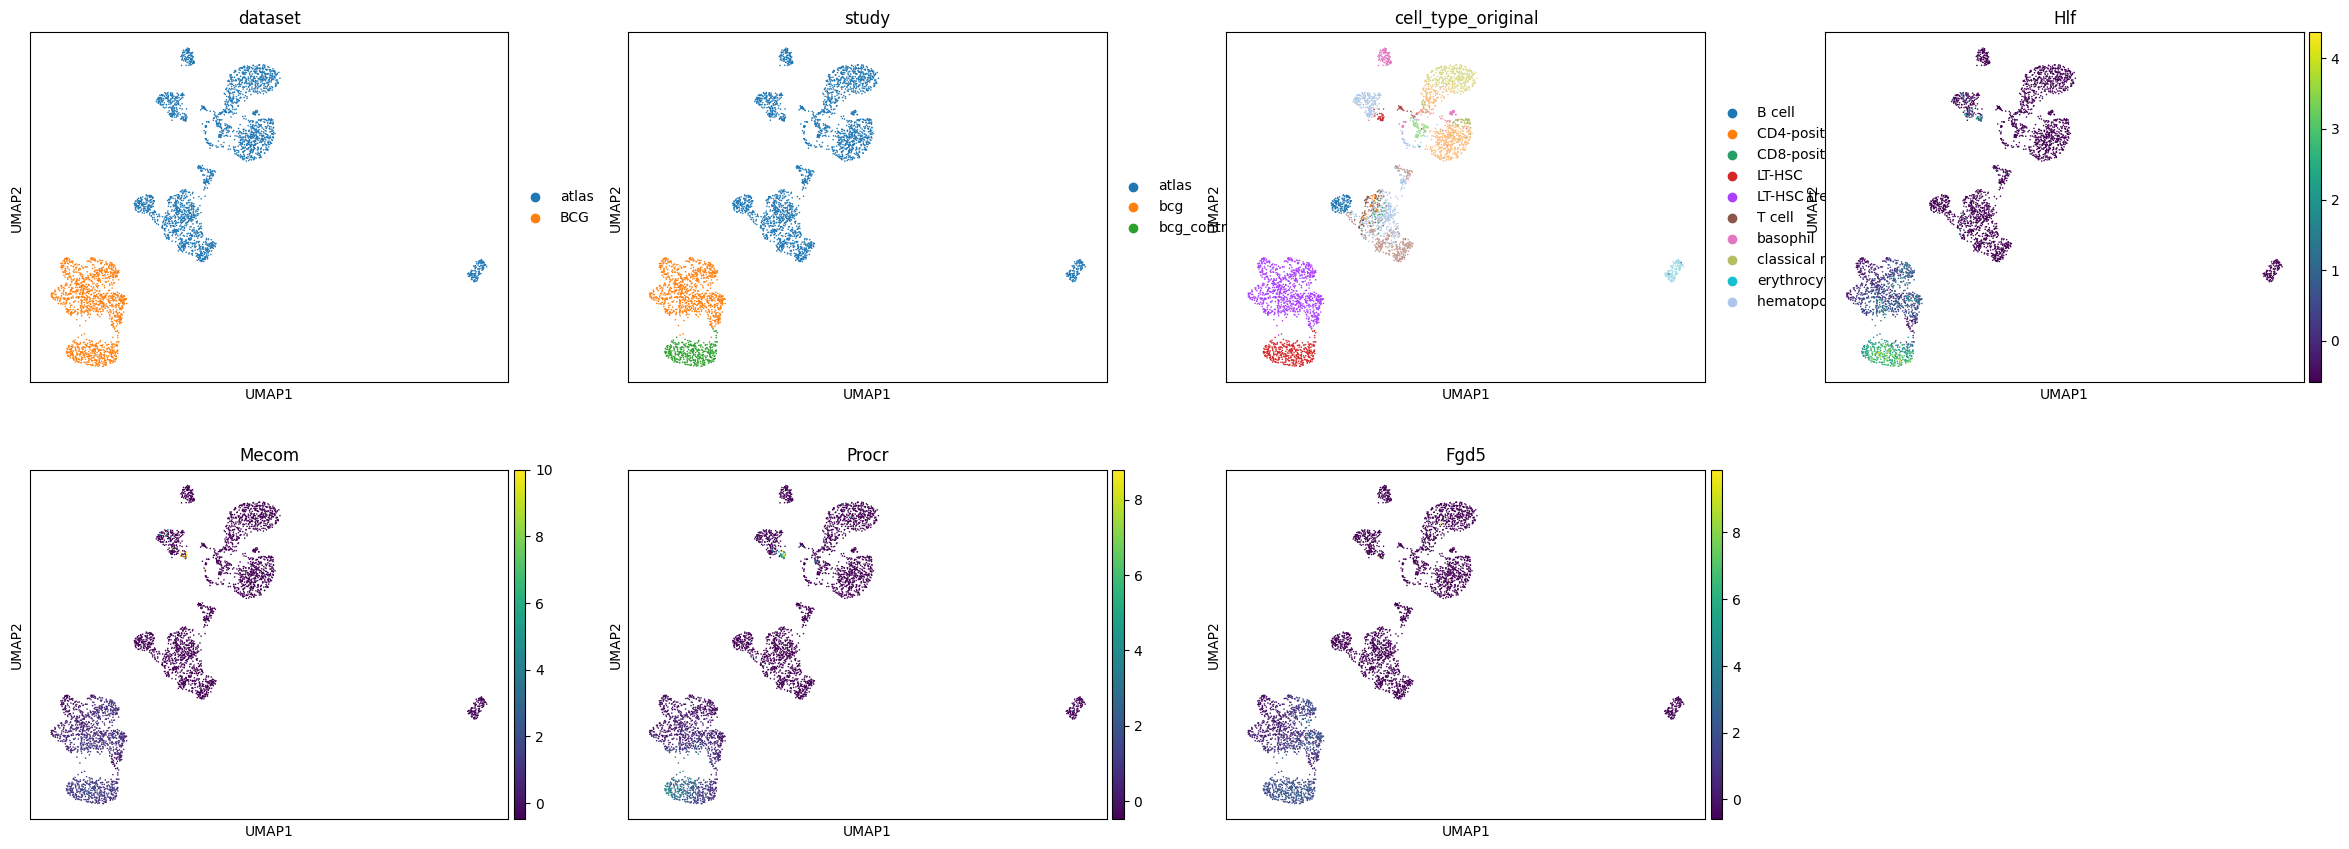

In [ ]:
combined = ad.concat(
    [atlas, bcg_aligned],
    label="dataset",
    keys=["atlas", "BCG"],
    join="inner"
)

# Standard preprocessing for UMAP
sc.pp.scale(combined, max_value=10)
sc.tl.pca(combined, svd_solver="arpack")

sc.pp.neighbors(combined, n_neighbors=15, n_pcs=30)
sc.tl.umap(combined)

sc.pl.umap(
    combined,
    color=["dataset", "study", "cell_type_original", "Hlf", "Mecom", "Procr", "Fgd5"],
    size=5
)

/n/sw/Miniforge3-24.7.1-0/lib/python3.12/functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


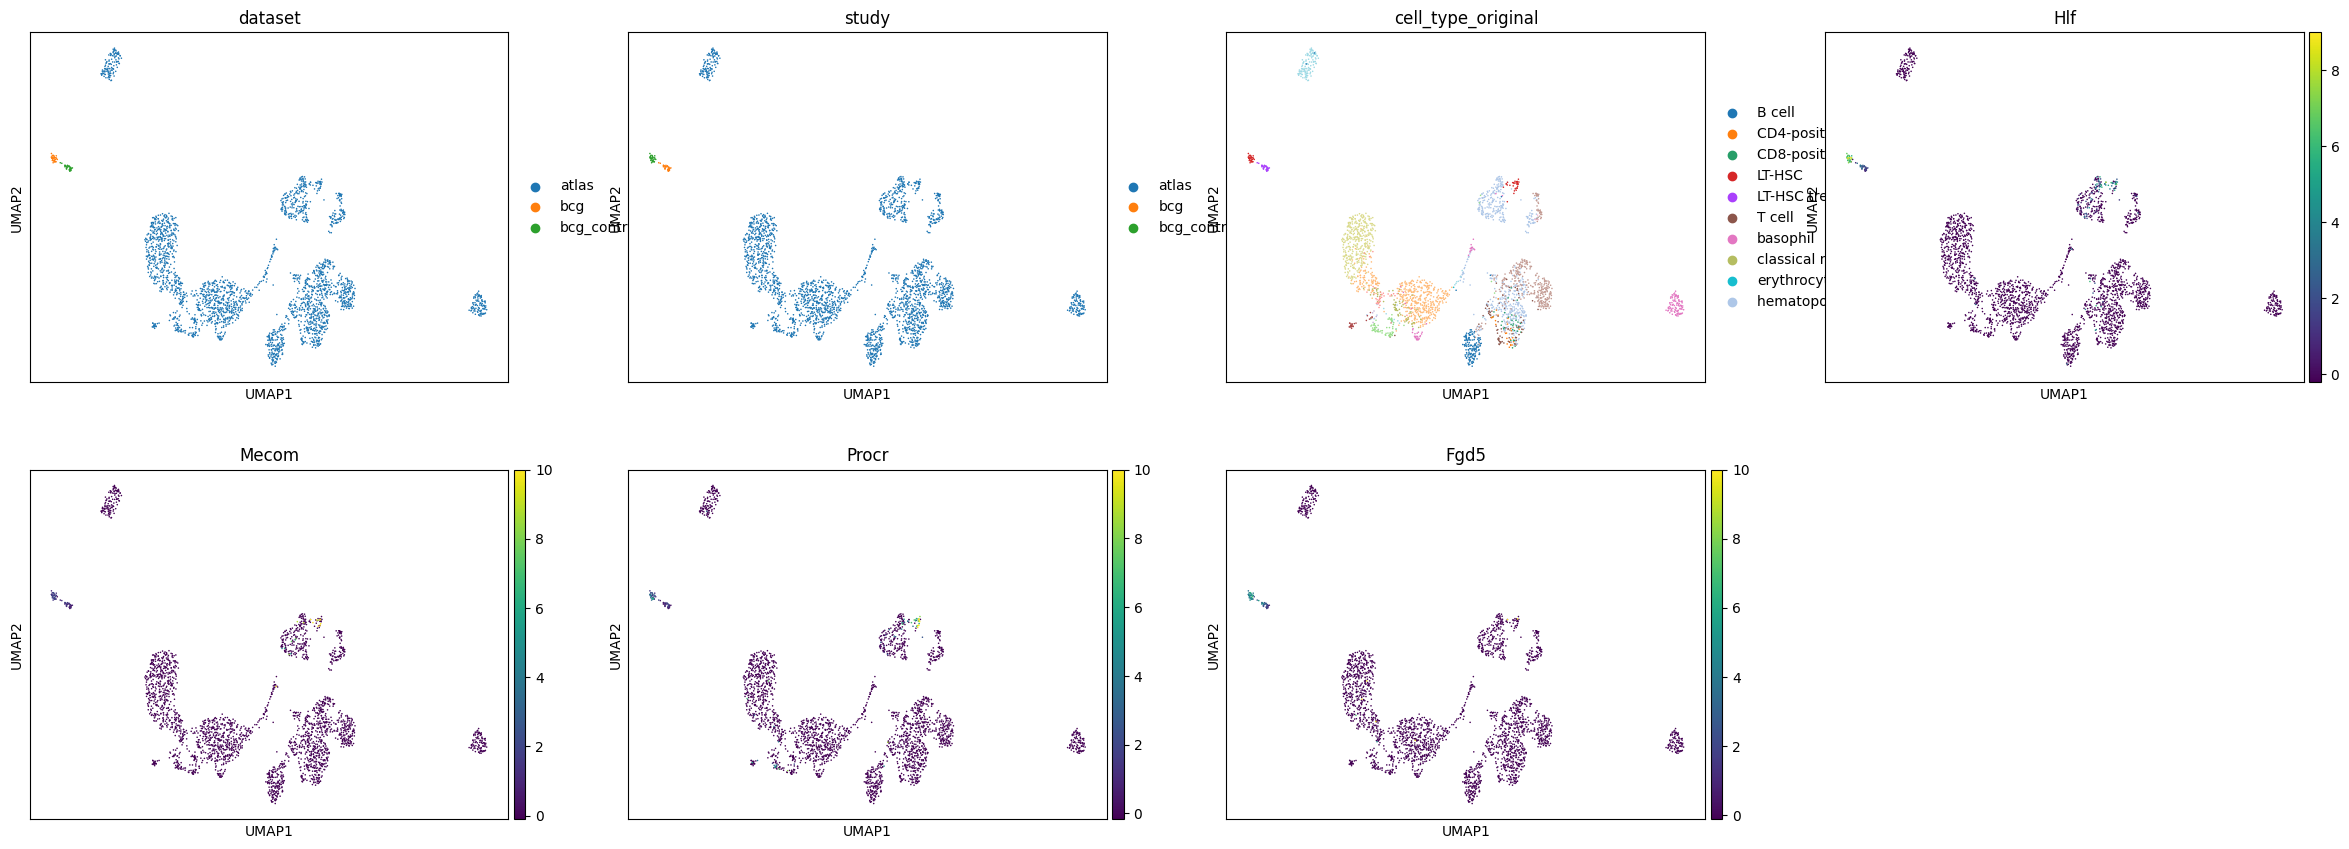

In [ ]:
rng = np.random.default_rng(0)

n_atlas_lthsc = np.sum(atlas.obs["cell_type_original"] == "LT-HSC")

bcg_lthsc = bcg_aligned[
    (bcg_aligned.obs["study"] == "bcg_control") &
    (bcg_aligned.obs["cell_type_original"] == "LT-HSC")
].copy()

bcg_control_lthsc_treated = bcg_aligned[
    (bcg_aligned.obs["study"] == "bcg") &
    (bcg_aligned.obs["cell_type_original"] == "LT-HSC treated")
].copy()

bcg_lthsc = bcg_lthsc[
    rng.choice(bcg_lthsc.n_obs, n_atlas_lthsc, replace=False)
].copy()

bcg_control_lthsc_treated = bcg_control_lthsc_treated[
    rng.choice(bcg_control_lthsc_treated.n_obs, n_atlas_lthsc, replace=False)
].copy()

combined = ad.concat(
    [
        atlas.copy(),
        bcg_lthsc.copy(),
        bcg_control_lthsc_treated.copy(),
    ],
    label="dataset",
    keys=["atlas", "bcg", "bcg_control"],
    join="inner"
)

sc.pp.scale(combined, max_value=10)
sc.tl.pca(combined, svd_solver="arpack")
sc.pp.neighbors(combined, n_neighbors=15, n_pcs=30)
sc.tl.umap(combined)

sc.pl.umap(
    combined,
    color=["dataset", "study", "cell_type_original", "Hlf", "Mecom", "Procr", "Fgd5"],
    size=5
)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


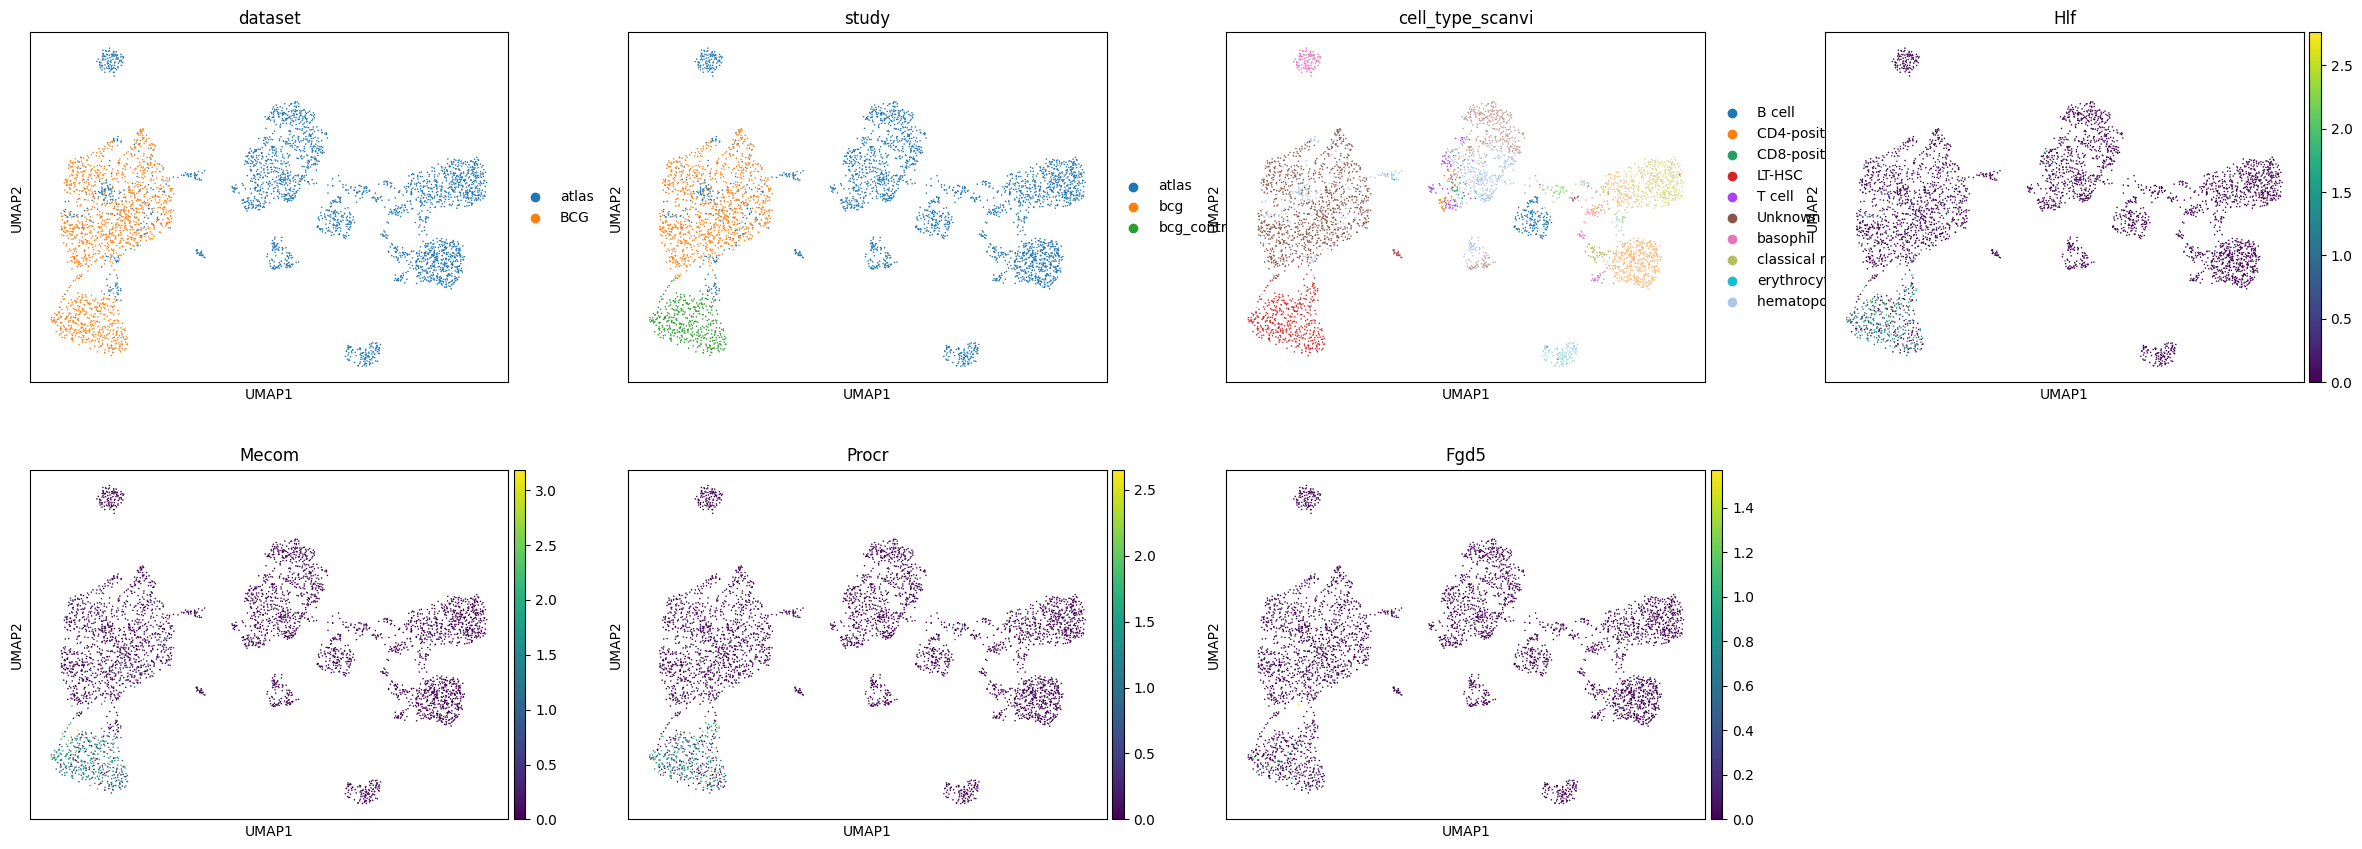

In [ ]:
combined_latent = ad.concat([atlas, bcg], label="dataset", keys=["atlas", "BCG"])

sc.pp.neighbors(combined_latent, use_rep="X_scANVI")
sc.tl.umap(combined_latent)

sc.pl.umap(
    combined_latent,
    color=["dataset", "study", "cell_type_scanvi", "Hlf", "Mecom", "Procr", "Fgd5"],
    size=5
)

In [ ]:
print(atlas.layers["counts"].max())
print(bcg.layers["counts"].max())

5511.0
668.0


Overlap looks good in latent space. Doesn't look good in decoded full dimensions.

In [ ]:
### Per-gene multiplicative anchor correction

In [ ]:
model_genes = atlas.var_names.intersection(bcg.var_names)

atlas_x = atlas[:, model_genes].copy()
bcg_x = bcg[:, model_genes].copy()

X_atlas = atlas_x.X.toarray() if sparse.issparse(atlas_x.X) else atlas_x.X.copy()
X_bcg = bcg_x.X.toarray() if sparse.issparse(bcg_x.X) else bcg_x.X.copy()

atlas_lthsc = atlas_x.obs["cell_type_scanvi"] == "LT-HSC"
bcg_lthsc = bcg_x.obs["cell_type_scanvi"] == "LT-HSC"

eps = 1e-6  # prevents divide-by-zero

atlas_mean = X_atlas[atlas_lthsc].mean(axis=0)
bcg_mean = X_bcg[bcg_lthsc].mean(axis=0)

ratio = (atlas_mean + eps) / (bcg_mean + eps)

X_bcg_aligned = X_bcg * ratio

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
bcg_mult_aligned = bcg_x.copy()
bcg_mult_aligned.X = X_bcg_aligned

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/n/sw/Miniforge3-24.7.1-0/lib/python3.12/functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


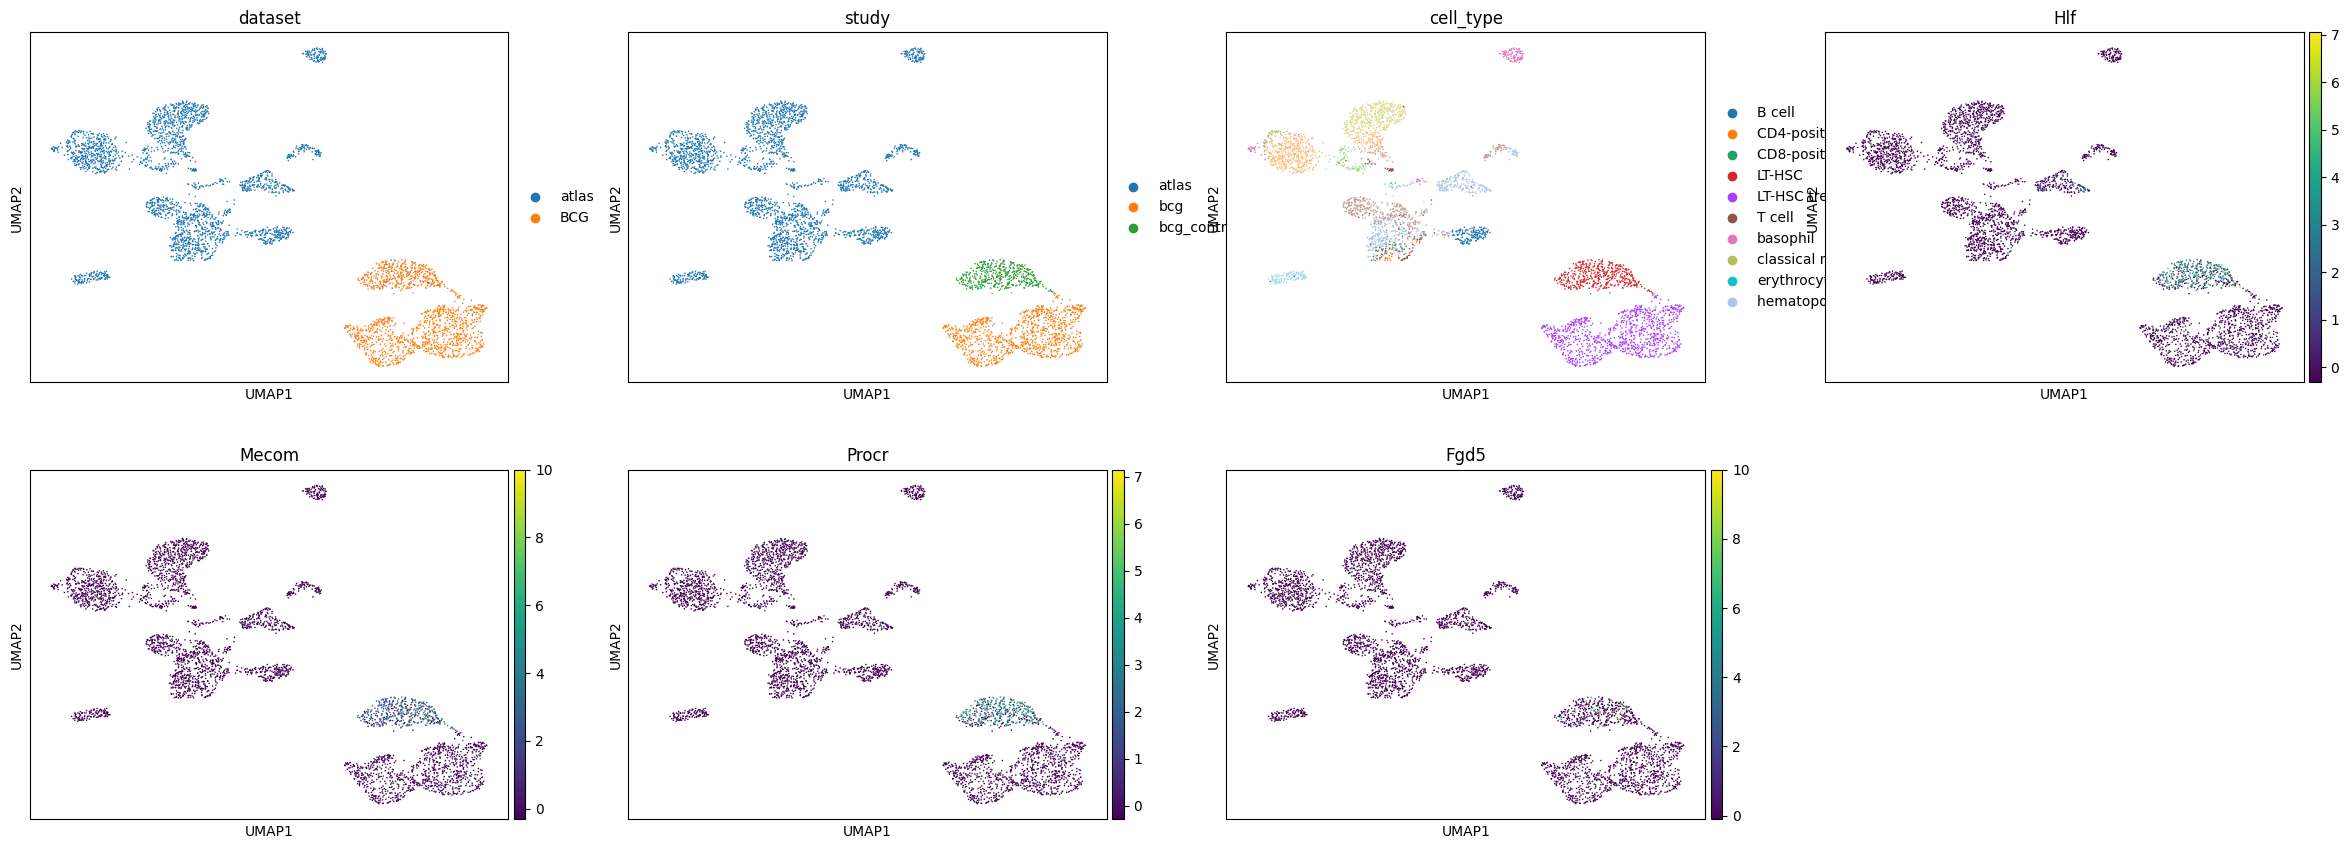

In [ ]:
combined_mult = ad.concat(
    [atlas[:, model_genes].copy(), bcg_mult_aligned],
    label="dataset",
    keys=["atlas", "BCG"],
    join="inner"
)

sc.pp.scale(combined_mult, max_value=10)
sc.tl.pca(combined_mult, svd_solver="arpack")
sc.pp.neighbors(combined_mult, n_neighbors=15, n_pcs=30)
sc.tl.umap(combined_mult)

sc.pl.umap(
    combined_mult,
    color=["dataset", "study", "cell_type", "Hlf", "Mecom", "Procr", "Fgd5"],
    size=5
)

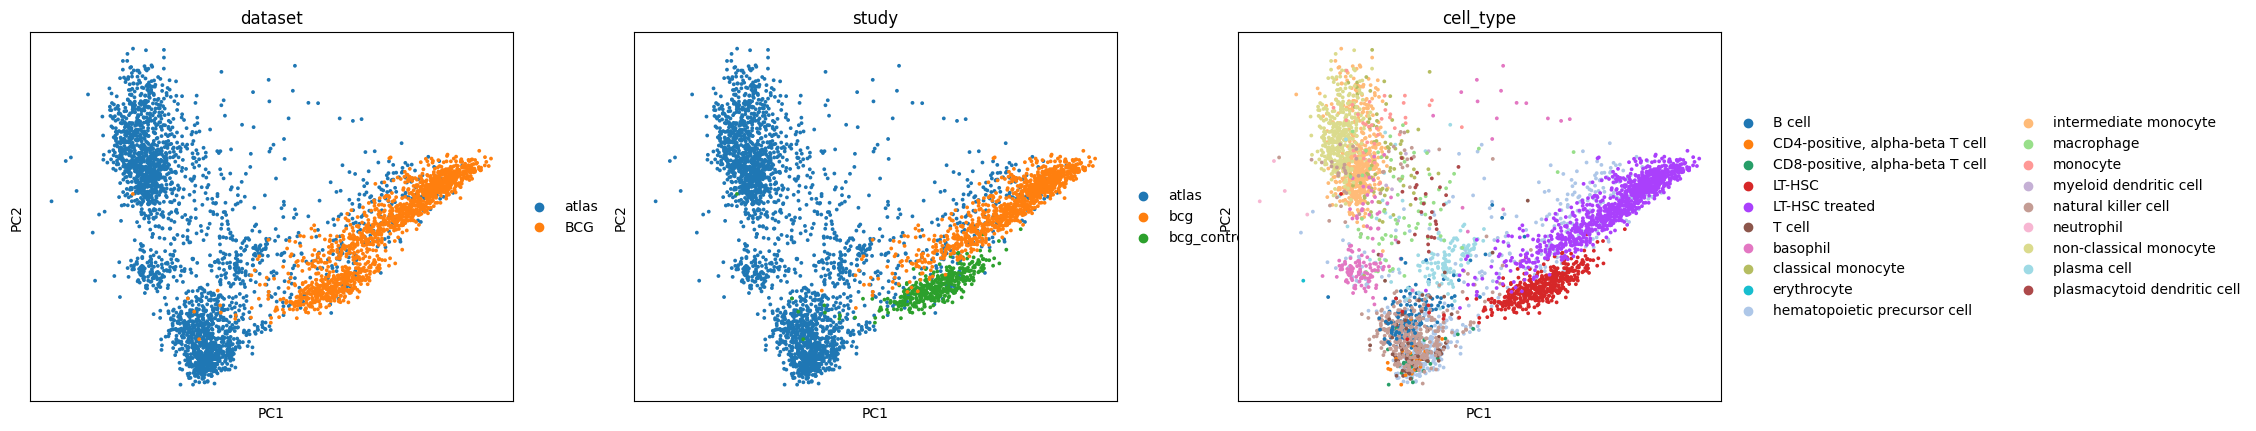

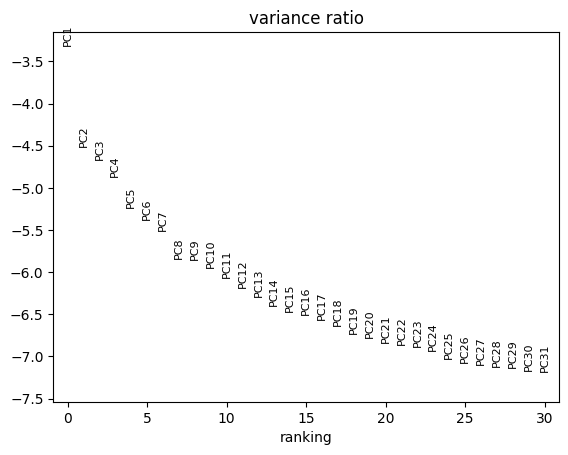

In [ ]:
# Plot PCA
sc.pl.pca(
    combined_mult,
    color=["dataset", "study", "cell_type"],
)

# Optional: variance explained
sc.pl.pca_variance_ratio(combined_mult, log=True)

In [ ]:
np.sum(bcg_mult_aligned.obs["cell_type"] == "LT-HSC")

np.int64(412)

In [ ]:
bcg_mult_aligned.obs[['cell_type','study']].value_counts()

cell_type       study      
LT-HSC treated  bcg            994
LT-HSC          bcg_control    412
Name: count, dtype: int64

/n/sw/Miniforge3-24.7.1-0/lib/python3.12/functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


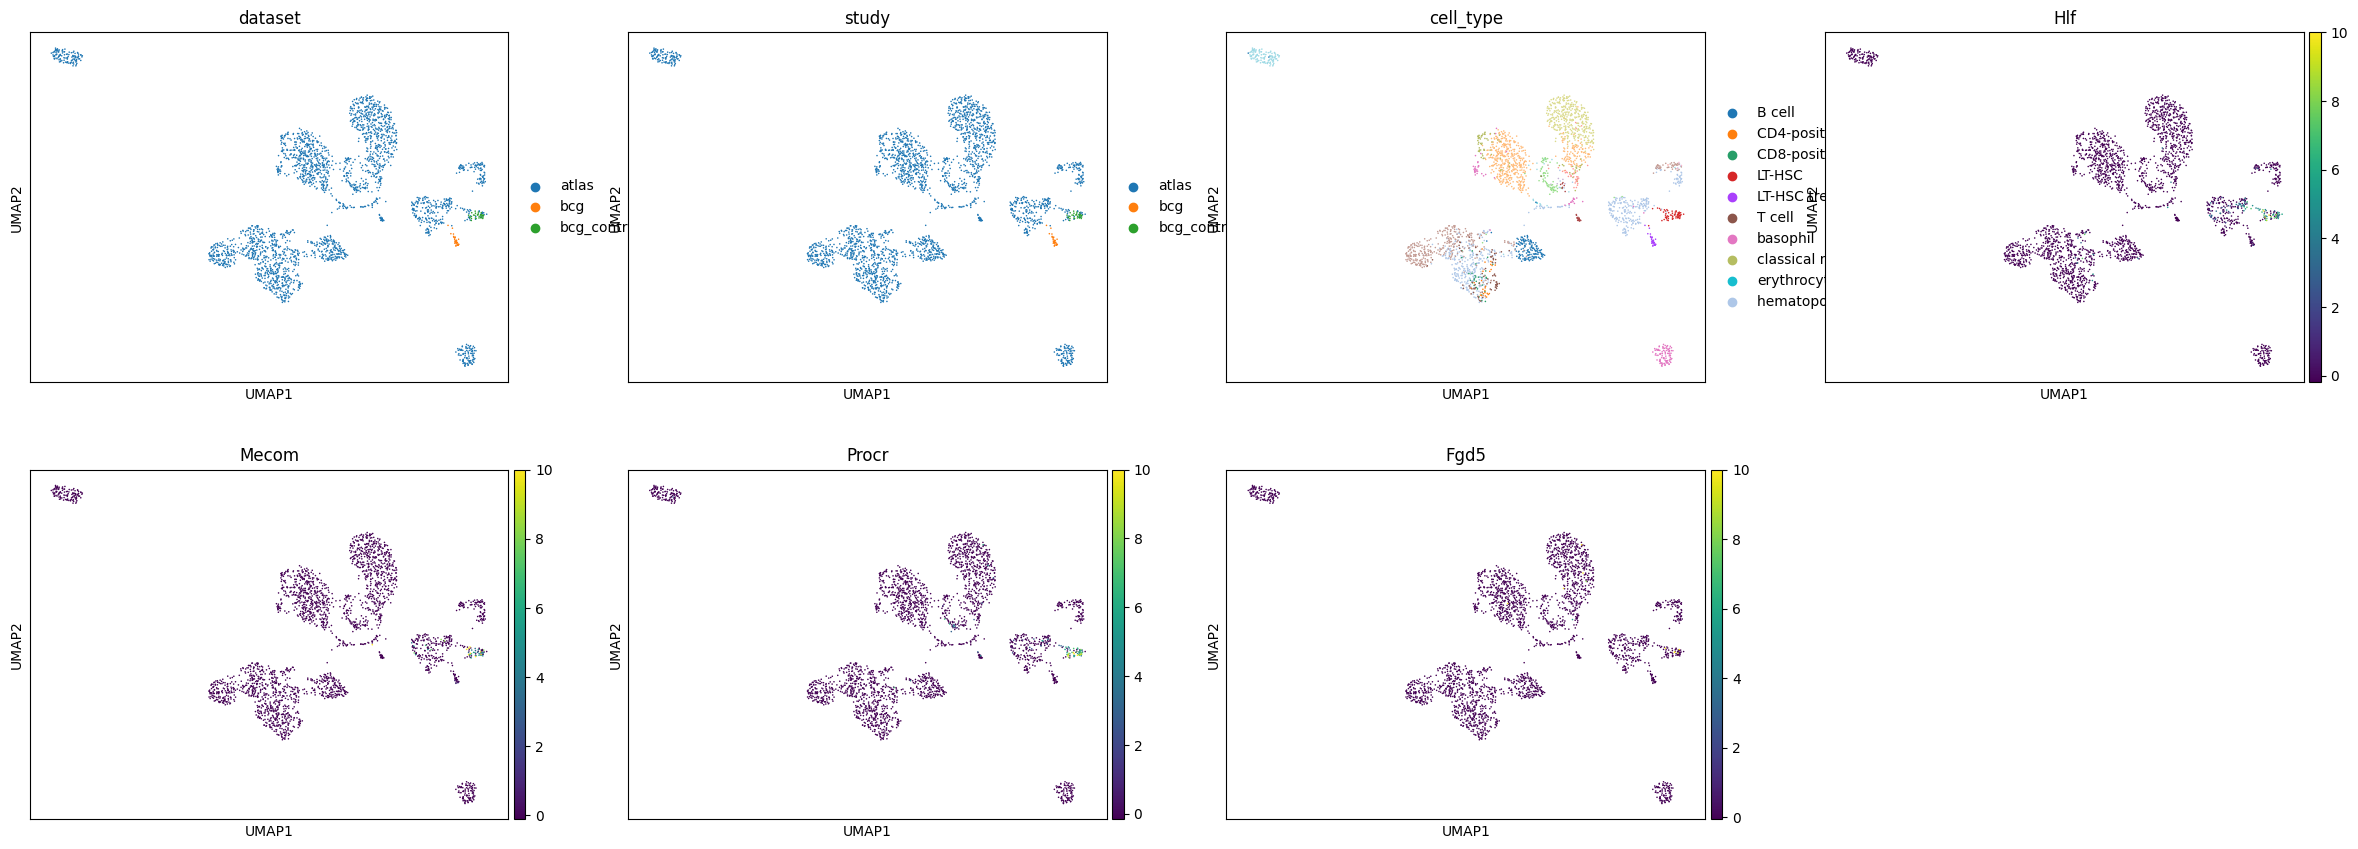

In [ ]:
import numpy as np
import anndata as ad
import scanpy as sc

rng = np.random.default_rng(0)

n_atlas_lthsc = np.sum(atlas.obs["cell_type"] == "LT-HSC")

bcg_lthsc = bcg_mult_aligned[
    (bcg_mult_aligned.obs["study"] == "bcg") &
    (bcg_mult_aligned.obs["cell_type"] == "LT-HSC treated")
].copy()

bcg_control_lthsc_treated = bcg_mult_aligned[
    (bcg_mult_aligned.obs["study"] == "bcg_control") &
    (bcg_mult_aligned.obs["cell_type"] == "LT-HSC")
].copy()

bcg_lthsc = bcg_lthsc[rng.choice(bcg_lthsc.n_obs, n_atlas_lthsc, replace=False)].copy()
bcg_control_lthsc_treated = bcg_control_lthsc_treated[
    rng.choice(bcg_control_lthsc_treated.n_obs, n_atlas_lthsc, replace=False)
].copy()

combined_mult = ad.concat(
    [
        atlas[:, model_genes].copy(),
        bcg_lthsc[:, model_genes].copy(),
        bcg_control_lthsc_treated[:, model_genes].copy(),
    ],
    label="dataset",
    keys=["atlas", "bcg", "bcg_control"],
    join="inner"
)

sc.pp.scale(combined_mult, max_value=10)
sc.tl.pca(combined_mult, svd_solver="arpack")
sc.pp.neighbors(combined_mult, n_neighbors=15, n_pcs=30)
sc.tl.umap(combined_mult)

sc.pl.umap(
    combined_mult,
    color=["dataset", "study", "cell_type", "Hlf", "Mecom", "Procr", "Fgd5"],
    size=5
)

In [ ]:
bcg_mult_aligned[
    (bcg_mult_aligned.obs["study"] == "bcg") &
    (bcg_mult_aligned.obs["cell_type"] == "LT-HSC")
].copy()

AnnData object with n_obs × n_vars = 0 × 10866
    obs: 'n_genes', 'leiden', 'cell_type', 'study', 'cell_type_original', 'cell_type_scanvi', '_scvi_batch', '_scvi_labels'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'study_colors', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap', 'X_scANVI'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [ ]:
bcg_mult_aligned.write("data/bcg_mouse_aligned_050626.h5ad")

### Previous batch correction attempt

In [ ]:
atlas = mouse_combined[mouse_combined.obs['study']=='atlas']

In [ ]:
bcg = mouse_combined[mouse_combined.obs['study'].isin(['bcg_control','bcg'])]

In [ ]:
atlas.obs["cell_type_scanvi"] = atlas.obs["cell_type"].astype(str)

scvi.model.SCVI.setup_anndata(
    atlas,
    layer="counts",
    batch_key="study"
)

vae = scvi.model.SCVI(atlas)
vae.train()

scanvi = scvi.model.SCANVI.from_scvi_model(
    vae,
    labels_key="cell_type",
    unlabeled_category="Unknown"
)
scanvi.train()

/tmp/ipykernel_255800/4177144441.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  atlas.obs["cell_type_scanvi"] = atlas.obs["cell_type"].astype(str)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speci ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/lightning/fabric/p

Epoch 400/400: 100%|██████████| 400/400 [11:45<00:00,  1.49s/it, v_num=1, train_loss=4.22e+3]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [11:45<00:00,  1.76s/it, v_num=1, train_loss=4.22e+3]
INFO     Training for 10 epochs.                                                                                   


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/scvi/data/fields/_dataframe_field.py:187: UserWarning: Category 7 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  categorical_mapping = _make_column_categorical(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/scvi/data/fields/_scanvi.py:56: UserWarning: Category 7 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  mapping = _make_column_categorical(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speci ...
GPU available: False, used: False
TPU available: False, using: 0

Epoch 10/10: 100%|██████████| 10/10 [00:19<00:00,  1.98s/it, v_num=1, train_loss=4.27e+3]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 10/10: 100%|██████████| 10/10 [00:19<00:00,  1.98s/it, v_num=1, train_loss=4.27e+3]


In [ ]:
bcg = bcg.copy()

scvi.model.SCVI.setup_anndata(
    bcg,
    layer="counts",
    batch_key="study"
)

bcg_query = scvi.model.SCANVI.load_query_data(bcg, scanvi)
bcg_query.train(max_epochs=100)

INFO     Training for 100 epochs.                                                                                  


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speci ...
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /n/holylabs/mooney_lab/Lab/joshprice/species

Epoch 100/100: 100%|██████████| 100/100 [01:02<00:00,  1.63it/s, v_num=1, train_loss=7.31e+3]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [01:02<00:00,  1.61it/s, v_num=1, train_loss=7.31e+3]


In [ ]:
bcg = bcg[:, atlas.var_names].copy()

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
atlas_aligned = atlas.copy()
bcg_aligned = bcg.copy()

In [ ]:
atlas_aligned.X = scanvi.get_normalized_expression(
    adata=atlas,
    transform_batch="atlas",
    library_size=1e4,
    return_numpy=True
)

bcg_aligned.X = bcg_query.get_normalized_expression(
    adata=bcg,
    transform_batch="atlas",
    library_size=1e4,
    return_numpy=True
)

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


In [ ]:
combined = ad.concat([atlas, bcg], label="study", keys=["atlas", "BCG"])

sc.pp.neighbors(combined)
sc.tl.umap(combined)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


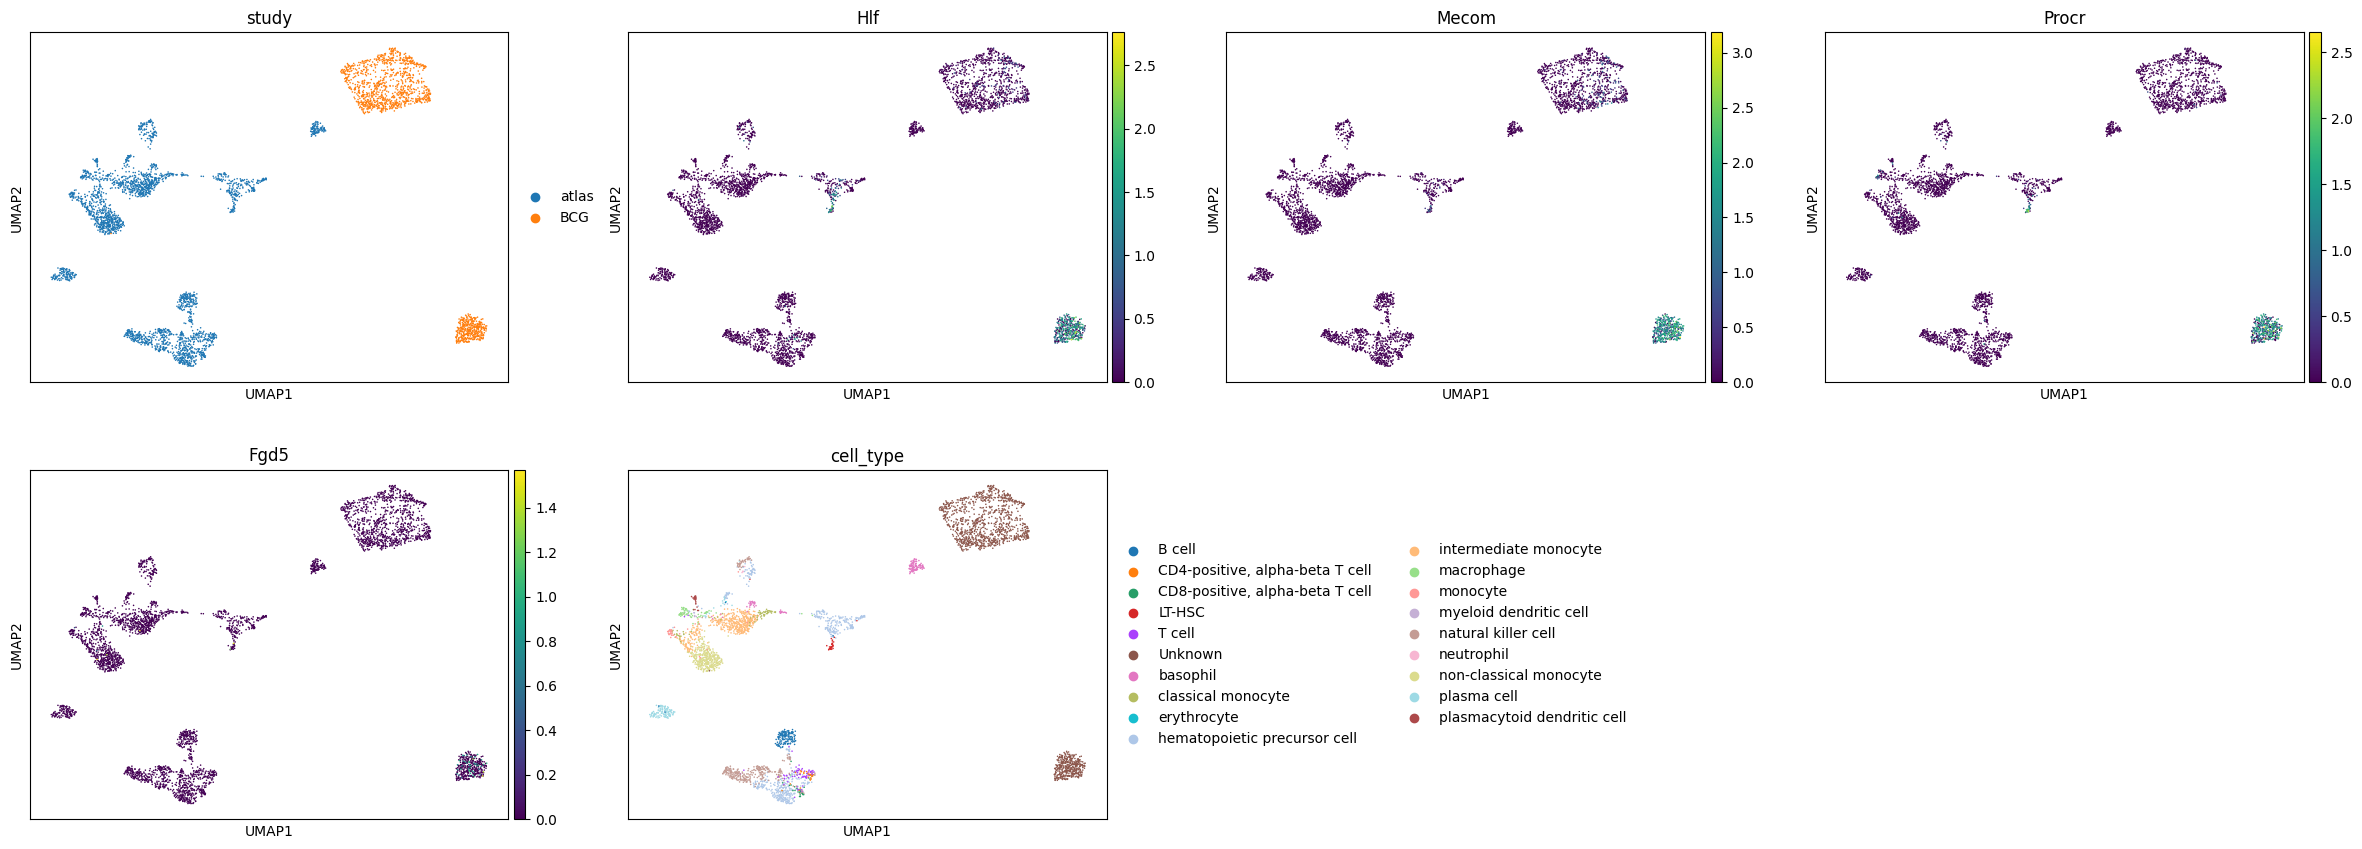

In [ ]:
sc.pl.umap(combined, color=["study", "Hlf", "Mecom", "Procr", "Fgd5", "cell_type"], size=5)

In [56]:
bcg

NameError: name 'bcg' is not defined

In [ ]:
bcg

AnnData object with n_obs × n_vars = 1406 × 10866
    obs: 'n_genes', 'leiden', 'cell_type', 'study', 'cell_type_scanvi', '_scvi_batch', '_scvi_labels'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'study_colors', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap', 'X_scANVI'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [ ]:
bcg_query.registry_["setup_args"]["batch_key"]
bcg_query.adata.obs[bcg_query.registry_["setup_args"]["batch_key"]].unique()

KeyError: None

In [ ]:
bcg.layers["X_atlas_aligned"] = bcg_query.get_normalized_expression(
    adata=bcg,
    transform_batch="atlas",
    library_size=1e4,
    return_numpy=True
)

ValueError: "atlas" not a valid batch category.